In [2]:
#从raw_data文件夹中读取csv数据，建立一个数组，数组中的每个元素是一个字典，字典的key是csv文件的列名，value是对应的值
import os
import csv
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 设置字体为 SimHei 以支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
new_path = r'd:\Desktop\PHD\reasearch\biyework\maml'
os.chdir(new_path)
# 检查当前路径是否切换成功
current_path = os.getcwd()
print(current_path)

d:\Desktop\PHD\reasearch\biyework\maml


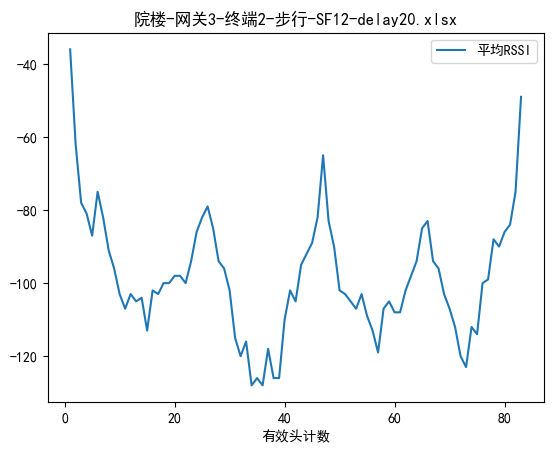

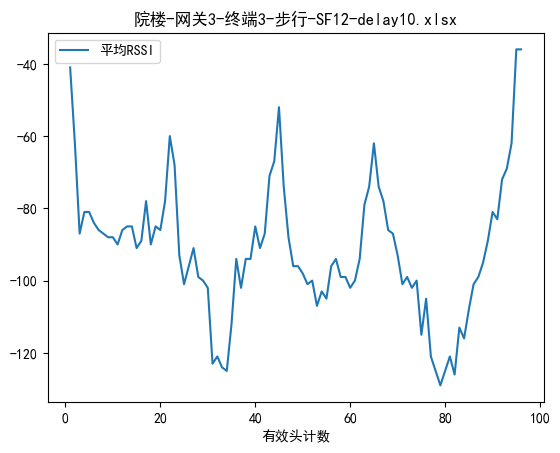

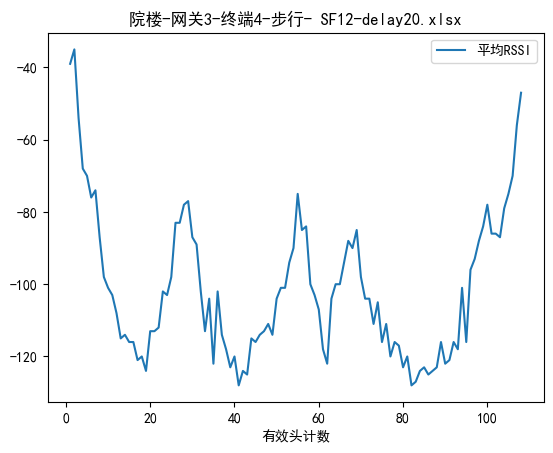

In [3]:
# 读取xlsx文件 dataProcessing\dataBaseStorage\raw_data\文件夹下的所有xlsx文件并且画图
# 读取文件夹下的所有xlsx文件
path = './dataProcessing/dataBaseStorage/raw_data/'
#path是相对路径，相对于当前文件的路径
if not os.path.exists(path):
    print(f"Path {path} does not exist.")
else:
    files = os.listdir(path)
for file in files:
    if not os.path.isdir(file):
        data = pd.read_excel(path + file)
        data.plot(x='有效头计数', y='平均RSSI')
        #设置这张图的名字
        plt.title(file)
        plt.show()
        #检测是否有文件夹./dataProcessing/dataBaseStorage/data_image/，有就先删除然后创建
        if not os.path.exists('./dataProcessing/dataBaseStorage/data_image/'):
            os.makedirs('./dataProcessing/dataBaseStorage/data_image/')
        plt.draw()  # 确保图像已经被正确绘制
        plt.savefig('./dataProcessing/dataBaseStorage/data_image/' + file+'.jpg') 
        plt.close()

In [4]:
# 给raw_data文件夹下的所有xlsx文件添加两列 代表 x和y坐标，
# 然后保存到dataProcessing\dataBaseStorage\processed_data\文件夹下，x y坐标随机生成，分布在5-15之间，保留两位小数
path = './dataProcessing/dataBaseStorage/raw_data/'
if not os.path.exists(path):
    print(f"path {path} does not exist.")
else:
    files = os.listdir(path)
for file in files:
    if not os.path.isdir(file):
        data = pd.read_excel(path + file)
        data['x'] = np.random.randint(0, 100, data.shape[0]) + np.random.rand(data.shape[0])
        data['y'] = np.random.randint(0, 100, data.shape[0]) + np.random.rand(data.shape[0])
        if not os.path.exists('./dataProcessing/dataBaseStorage/processed_data/'):
            os.makedirs('./dataProcessing/dataBaseStorage/processed_data/')
        data.to_excel('./dataProcessing/dataBaseStorage/processed_data/' + file, index=False)
        print(f"file {file} has been processed and saved.")

file 院楼-网关3-终端2-步行-SF12-delay20.xlsx has been processed and saved.
file 院楼-网关3-终端3-步行-SF12-delay10.xlsx has been processed and saved.
file 院楼-网关3-终端4-步行- SF12-delay20.xlsx has been processed and saved.


在克里金插值中，变差函数（Variogram）是一个核心概念，用于描述区域化变量的空间变异性，以下为你详细介绍：定义与数学表达设区域化变量为 $Z(x)$，在空间位置 x 和 $x+h$ 处取值，变差函数$\gamma(x,h)$ 定义为：
$$\gamma(x,h)=\frac{1}{2}E[Z(x)-Z(x + h)]^{2}$$
其中，h 是空间滞后距（两点之间的距离和方向），E 表示数学期望。简单来说，它衡量的是空间上相距 h 的两点处变量值差异的平方的一半。


* 块金效应（Nugget Effect）：
当 \(h = 0\) 时，理论上变差函数值应为 0，但实际中由于测量误差、微观尺度变异等因素，会存在一个非零值，这就是块金效应。它反映了小于观测尺度下的变异性以及测量误差等。
* 变程（Range） ：
随着滞后距 h 增加，变差函数值会逐渐增大并趋于稳定，达到稳定时对应的 h 值就是变程。在变程内，变量具有空间自相关性；超出变程，变量间相关性可忽略，可视为相互独立。
* 基台值（Sill）：
变差函数达到稳定时的值就是基台值，分为偏基台值（Partial Sill）和总基台值（Full Sill）。总基台值是区域化变量的总变异性，等于块金效应与偏基台值之和，代表了区域化变量在空间上的最大变异性。

nlag对变差函数拟合的影响：**将数据点之间的距离分成nlags个部分** 去计算变差函数中的$h$
1. nlags过小，变差函数的分辨率会很低，拟合不够精细
2. nlags过大，一般比较精细但是计算量会加大
***
OrdinaryKriging 会生成变差函数图，图像中包含以下内容：
1. 横坐标（Lag Distance）：表示数据点之间的距离。
2. 纵坐标（Semivariance）：表示数据点对之间的半方差值。
3. 数据点（Stars or Dots）：表示实际数据点对的半方差值。
4. 拟合曲线（Fitted Variogram Model）：表示拟合的变差函数模型。
***
变差函数的计算过程
数据点对：

假设你有 n 个数据点，每个数据点有一个位置（x, y）和一个值（例如 RSSI）。
数据点对是指任意两个数据点之间的组合。对于 n 个数据点，总共有 n*(n-1)/2 个数据点对。

滞后距离（lag distance）：

滞后距离是指数据点对之间的距离。计算所有数据点对之间的距离。
根据 nlags 参数，将这些距离划分为若干个间隔。例如，如果 nlags=20，则将数据点对之间的距离划分为 20 个间隔。

半方差（semivariance）：

对于每个滞后距离间隔，计算该间隔内所有数据点对的半方差值。
半方差的计算公式为： $$\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [Z(x_i) - Z(x_i + h)]^2$$ 其中，$\gamma(h)$ 是滞后距离 $(h)$ 处的半方差值，$(N(h))$ 是滞后距离 $(h)$ 处的数据点对数目，$Z(x_i)$ 和 $Z(x_i + h)$ 是距离为 $(h)$ 的两个数据点的值。

在计算变差函数时，$N(h)$ 代表的是滞后距离在某个区间内的数据点对的数量。具体来说，$N(h)$ 是指距离在某个滞后距离区间内的数据点对的数量，而不是精确相差距离为 $h$ 的点对

file 院楼-网关3-终端2-步行-SF12-delay20.xlsx has been processed and saved.
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 2.495952051848696e-16
Full Sill: 208.51340250584752
Range: 134.4525004156162
Nugget: 208.51340250584752 



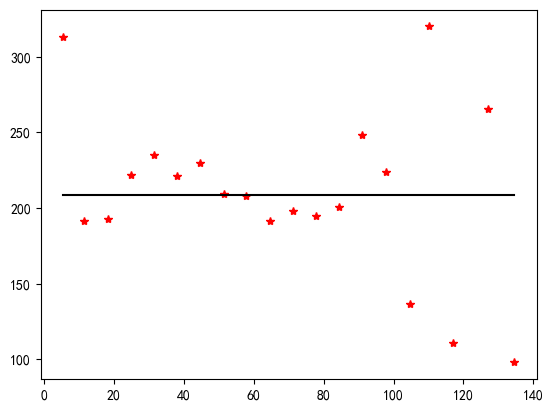

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



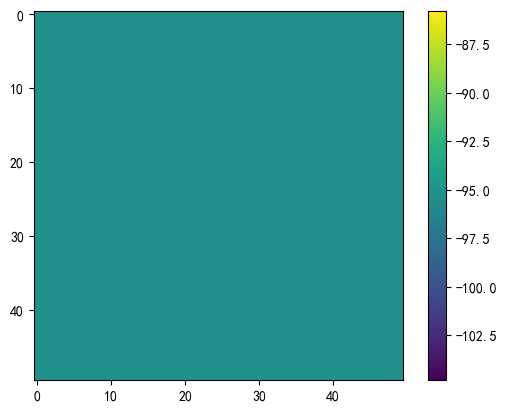

file 院楼-网关3-终端2-步行-SF12-delay20.xlsx has been interpolated and saved.
file 院楼-网关3-终端3-步行-SF12-delay10.xlsx has been processed and saved.
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 96.63693454635703
Full Sill: 351.27085447546585
Range: 122.20899239213475
Nugget: 254.6339199291088 



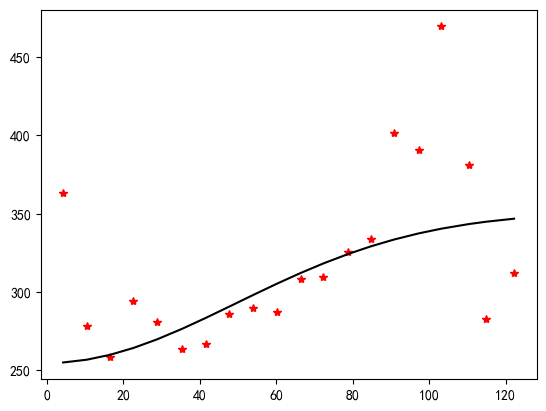

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



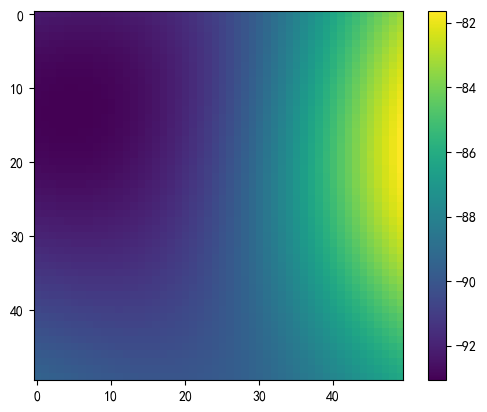

file 院楼-网关3-终端3-步行-SF12-delay10.xlsx has been interpolated and saved.
file 院楼-网关3-终端4-步行- SF12-delay20.xlsx has been processed and saved.
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 121.0584636902649
Full Sill: 294.4674715201478
Range: 4.913561407664984
Nugget: 173.4090078298829 



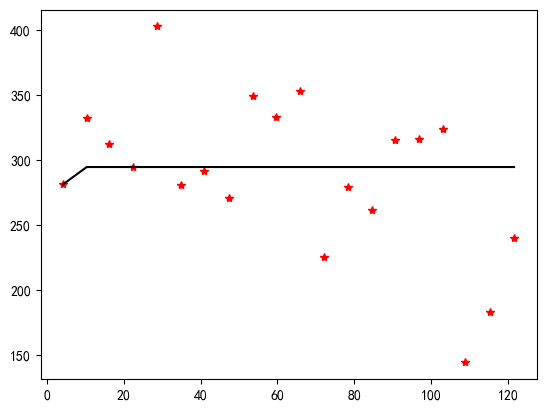

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



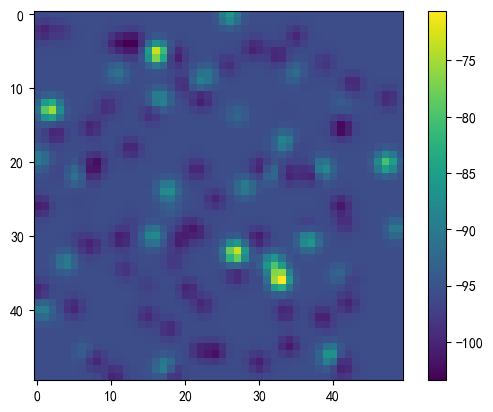

file 院楼-网关3-终端4-步行- SF12-delay20.xlsx has been interpolated and saved.


In [14]:
# 读取dataProcessing\dataBaseStorage\processed_data\文件夹下的所有xlsx文件，
# 提取 有效头计数 实时RSSI x y 四列数据,
from pykrige.ok import OrdinaryKriging
path='./dataProcessing/dataBaseStorage/processed_data/'
files=os.listdir(path)
for file in files:
    if not os.path.isdir(file):
        data = pd.read_excel(path + file)
        data = data[['有效头计数', '实时RSSI', 'x', 'y']]
    if not os.path.exists('./dataProcessing/dataBaseStorage/new_processed_data/'):
        os.makedirs('./dataProcessing/dataBaseStorage/new_processed_data/')
    data.to_csv('./dataProcessing/dataBaseStorage/new_processed_data/' + file[:-5] + '.csv', index=False)
    print(f"file {file} has been processed and saved.")
    # 使用克里金插值方法，根据xy坐标对实时RSSI进行插值，然后画图
    # 读取csv文件
    data=pd.read_csv('./dataProcessing/dataBaseStorage/new_processed_data/' + file[:-5] + '.csv')
    #克里金插值方法
    ok=OrdinaryKriging(data['x'],data['y'],data['实时RSSI'],
                   variogram_model='gaussian',verbose=True,
                   enable_plotting=True,nlags=20)
    #0-100生成50个等间距点进行插值
    gridx = np.linspace(0, 100, 50)
    gridy = np.linspace(0, 100, 50)
    z,ss=ok.execute('grid',gridx,gridy)
    plt.imshow(z)
    plt.colorbar()
    plt.show()
    #将插值后的数据保存到dataProcessing\dataBaseStorage\interpolated_data\文件夹下
    if not os.path.exists('./dataProcessing/dataBaseStorage/interpolated_data/'):
        os.makedirs('./dataProcessing/dataBaseStorage/interpolated_data/')
    # 生成插值网格的 x 和 y 坐标
    gridx, gridy = np.meshgrid(gridx, gridy)
    
    # 将插值结果 z 展开为一维数组
    x_flat = gridx.flatten()
    y_flat = gridy.flatten()
    z_flat = z.flatten()
    
    # 将 x 坐标、y 坐标和插值结果组合成一个 DataFrame
    interpolated_data = pd.DataFrame({'x': x_flat, 'y': y_flat, 'rssi': z_flat})
    
    # 将 DataFrame 保存为 CSV 文件
    interpolated_data.to_csv('./dataProcessing/dataBaseStorage/interpolated_data/' + file[:-5] + '_interpolated.csv', index=False)
    print(f"file {file} has been interpolated and saved.")